# APS Dataset Exploration

This notebook explores the structure and contents of the APS (American Physical Society) dataset (2022 version).

The dataset has two parts:
1. **Citations CSV** (`aps-dataset-citations-2022.csv`): ~9.8M citation edges (citing_doi → cited_doi)
2. **Metadata JSONs** (`aps-dataset-metadata-2022/`): Individual JSON files per paper, organized by journal

In [1]:
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

BASE_DIR = Path('/gpfs/kellogg/proj/dashun/abbey/APS')
CITATIONS_FILE = BASE_DIR / 'aps-dataset-citations-2022.csv'
METADATA_DIR = BASE_DIR / 'aps-dataset-metadata-2022'

## 1. Citations Data

In [2]:
# Load citations data
citations = pd.read_csv(CITATIONS_FILE)
print(f'Shape: {citations.shape}')
print(f'Columns: {citations.columns.tolist()}')
citations.head(10)

Shape: (9833191, 2)
Columns: ['citing_doi', 'cited_doi']


,citing_doi,cited_doi
0,10.1103/PhysRevSeriesI.11.215,10.1103/PhysRevSeriesI.1.1
1,10.1103/PhysRevSeriesI.12.121,10.1103/PhysRevSeriesI.1.166
2,10.1103/PhysRevSeriesI.7.93,10.1103/PhysRevSeriesI.1.166
3,10.1103/PhysRevSeriesI.16.267,10.1103/PhysRevSeriesI.2.35
4,10.1103/PhysRevSeriesI.17.65,10.1103/PhysRevSeriesI.2.112
5,10.1103/PhysRevSeriesI.17.65,10.1103/PhysRevSeriesI.2.161
6,10.1103/PhysRevSeriesI.11.215,10.1103/PhysRevSeriesI.2.161
7,10.1103/PhysRevSeriesI.13.65,10.1103/PhysRevSeriesI.2.260
8,10.1103/PhysRevSeriesI.23.125,10.1103/PhysRevSeriesI.2.424
9,10.1103/PhysRevSeriesI.7.35,10.1103/PhysRevSeriesI.3.49


In [3]:
# Basic stats
print(f'Total citation edges: {len(citations):,}')
print(f'Unique citing papers: {citations["citing_doi"].nunique():,}')
print(f'Unique cited papers: {citations["cited_doi"].nunique():,}')
print(f'Any nulls:\n{citations.isnull().sum()}')

Total citation edges: 9,833,191
Unique citing papers: 693,706
Unique cited papers: 625,223
Any nulls:
citing_doi    0
cited_doi     0
dtype: int64


In [4]:
# Distribution of references per citing paper
refs_per_paper = citations.groupby('citing_doi').size()
print('References per paper:')
print(refs_per_paper.describe())
print(f'\nMedian: {refs_per_paper.median()}')
print(f'Papers with >= 5 refs: {(refs_per_paper >= 5).sum():,} ({(refs_per_paper >= 5).mean():.1%})')

References per paper:
count    693706.000000
mean         14.174868
std          12.687776
min           1.000000
25%           6.000000
50%          11.000000
75%          19.000000
max         607.000000
dtype: float64

Median: 11.0
Papers with >= 5 refs: 570,400 (82.2%)


In [5]:
# Distribution of citations received per cited paper
cits_per_paper = citations.groupby('cited_doi').size()
print('Citations received per paper:')
print(cits_per_paper.describe())
print(f'\nMedian: {cits_per_paper.median()}')
print(f'Top 10 most cited:')
print(cits_per_paper.nlargest(10))

Citations received per paper:
count    625223.000000
mean         15.727494
std          53.699264
min           1.000000
25%           3.000000
50%           7.000000
75%          15.000000
max       14357.000000
dtype: float64

Median: 7.0
Top 10 most cited:
cited_doi
10.1103/PhysRevLett.77.3865    14357
10.1103/PhysRevB.54.11169       9984
10.1103/PhysRev.140.A1133       8588
10.1103/PhysRevB.50.17953       7368
10.1103/PhysRevB.59.1758        6972
10.1103/PhysRev.136.B864        6932
10.1103/RevModPhys.82.3045      6084
10.1103/PhysRevB.13.5188        5985
10.1103/PhysRevB.23.5048        5038
10.1103/RevModPhys.83.1057      4673
dtype: int64


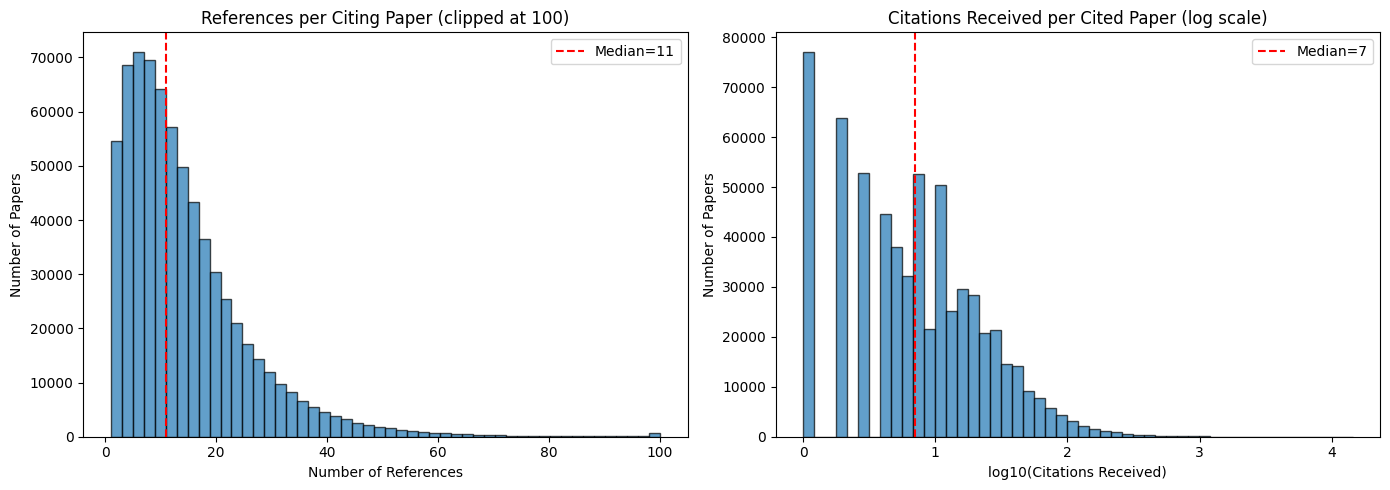

In [6]:
# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(refs_per_paper.clip(upper=100), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of References')
axes[0].set_ylabel('Number of Papers')
axes[0].set_title('References per Citing Paper (clipped at 100)')
axes[0].axvline(refs_per_paper.median(), color='red', linestyle='--', label=f'Median={refs_per_paper.median():.0f}')
axes[0].legend()

axes[1].hist(np.log10(cits_per_paper), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log10(Citations Received)')
axes[1].set_ylabel('Number of Papers')
axes[1].set_title('Citations Received per Cited Paper (log scale)')
axes[1].axvline(np.log10(cits_per_paper.median()), color='red', linestyle='--', label=f'Median={cits_per_paper.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# What journals appear in the citations?
# DOI format: 10.1103/PhysRevA.1.1 -> extract journal from DOI
def extract_journal_from_doi(doi):
    """Extract journal abbreviation from APS DOI."""
    try:
        parts = doi.split('/')
        if len(parts) >= 2:
            journal_part = parts[1].split('.')[0]
            return journal_part
    except:
        pass
    return 'Unknown'

# Sample to check DOI patterns
sample_dois = citations['citing_doi'].head(20).tolist()
for doi in sample_dois[:5]:
    print(f'{doi} -> {extract_journal_from_doi(doi)}')

10.1103/PhysRevSeriesI.11.215 -> PhysRevSeriesI
10.1103/PhysRevSeriesI.12.121 -> PhysRevSeriesI
10.1103/PhysRevSeriesI.7.93 -> PhysRevSeriesI
10.1103/PhysRevSeriesI.16.267 -> PhysRevSeriesI
10.1103/PhysRevSeriesI.17.65 -> PhysRevSeriesI


In [8]:
# Journal distribution among citing papers
citing_journals = citations['citing_doi'].apply(extract_journal_from_doi)
print('Citing paper journals:')
print(citing_journals.value_counts().head(20))

Citing paper journals:
citing_doi
PhysRevB              3338799
PhysRevD              1651685
PhysRevLett           1356747
PhysRevA              1323243
PhysRevE               700250
PhysRevC               623286
PhysRev                292285
RevModPhys             151703
PhysRevResearch        124645
PhysRevApplied          70543
PhysRevMaterials        64486
PhysRevX                60720
PhysRevFluids           20162
PRXQuantum              16000
PhysRevAccelBeams       13014
PhysRevSTAB             12009
Physics                  6104
PhysRevPhysEducRes       5545
PhysRevSTPER             1167
PRXEnergy                 281
Name: count, dtype: int64


In [9]:
# Check: do citations go outside APS? (cited papers from non-APS journals)
cited_journals = citations['cited_doi'].apply(extract_journal_from_doi)
print('Cited paper journals:')
print(cited_journals.value_counts().head(20))
print(f'\nNote: This dataset only contains APS-to-APS citations (both citing and cited are APS papers).')

Cited paper journals:
cited_doi
PhysRevLett              3175040
PhysRevB                 2404898
PhysRevD                 1328599
PhysRevA                  910391
PhysRev                   725571
PhysRevC                  453613
PhysRevE                  394706
RevModPhys                298236
PhysRevX                   61807
PhysRevResearch            18162
PhysRevApplied             17019
PhysRevSTAB                13098
PhysRevMaterials            8582
PhysRevFluids               5146
PhysRevSTPER                4036
PhysicsPhysiqueFizika       3689
PhysRevAccelBeams           3049
PhysRevPhysEducRes          2614
PRXQuantum                  2366
Physics                     2230
Name: count, dtype: int64

Note: This dataset only contains APS-to-APS citations (both citing and cited are APS papers).


## 2. Metadata Structure

In [10]:
# List journals in metadata
journals = sorted([d.name for d in METADATA_DIR.iterdir() if d.is_dir()])
print(f'Journals in metadata: {len(journals)}')
for j in journals:
    n_files = sum(1 for _ in (METADATA_DIR / j).rglob('*.json'))
    print(f'  {j}: {n_files:,} papers')

Journals in metadata: 13
  PR: 47,940 papers
  PRA: 88,357 papers
  PRAB: 1,566 papers
  PRAPPLIED: 5,295 papers
  PRB: 154,009 papers
  PRFLUIDS: 3,524 papers
  PRI: 1,469 papers
  PRMATERIALS: 3,951 papers
  PRPER: 693 papers
  PRRESEARCH: 4,813 papers
  PRSTPER: 368 papers
  PRXQUANTUM: 497 papers
  RMP: 3,494 papers


In [11]:
# Load a sample of metadata to understand the schema
sample_file = next((METADATA_DIR / 'PRA' / '1').glob('*.json'))
with open(sample_file) as f:
    sample = json.load(f)

print('Top-level keys:')
for key in sample.keys():
    val = sample[key]
    if isinstance(val, dict):
        print(f'  {key}: dict with keys {list(val.keys())}')
    elif isinstance(val, list):
        print(f'  {key}: list of {len(val)} items')
        if val:
            if isinstance(val[0], dict):
                print(f'    first item keys: {list(val[0].keys())}')
    else:
        print(f'  {key}: {type(val).__name__} = {val}')

Top-level keys:
  id: str = 10.1103/PhysRevA.1.411
  title: dict with keys ['value', 'format']
  publisher: dict with keys ['name']
  journal: dict with keys ['id', 'abbreviatedName', 'name']
  issue: dict with keys ['number']
  volume: dict with keys ['number']
  pageStart: str = 411
  pageEnd: str = 418
  seqnum: int = 1
  date: str = 1970-02-01
  numPages: int = 7
  articleType: str = article
  identifiers: dict with keys ['doi']
  rights: dict with keys ['copyrightYear', 'copyrightHolders']
  authors: list of 3 items
    first item keys: ['type', 'name', 'firstname', 'surname', 'affiliationIds']
  affiliations: list of 1 items
    first item keys: ['id', 'name']


In [12]:
# Pretty print full sample
print(json.dumps(sample, indent=2))

{
  "id": "10.1103/PhysRevA.1.411",
  "title": {
    "value": "Mechanism of Ultrasonic Cavitation Nucleation in Liquid Helium by Quantized Vortices",
    "format": "html+mathml"
  },
  "publisher": {
    "name": "APS"
  },
  "journal": {
    "id": "PRA",
    "abbreviatedName": "Phys. Rev. A",
    "name": "Physical Review A"
  },
  "issue": {
    "number": "2"
  },
  "volume": {
    "number": "1"
  },
  "pageStart": "411",
  "pageEnd": "418",
  "seqnum": 1,
  "date": "1970-02-01",
  "numPages": 7,
  "articleType": "article",
  "identifiers": {
    "doi": "10.1103/PhysRevA.1.411"
  },
  "rights": {
    "copyrightYear": 1970,
    "copyrightHolders": [
      {
        "type": "organization",
        "name": "The American Physical Society"
      }
    ]
  },
  "authors": [
    {
      "type": "Person",
      "name": "P. M. McConnell",
      "firstname": "P. M.",
      "surname": "McConnell",
      "affiliationIds": [
        "a1"
      ]
    },
    {
      "type": "Person",
      "name": "M

In [13]:
# Load a few more samples from different journals to see if schema varies
sample_journals = ['PR', 'PRB', 'RMP', 'PRRESEARCH']
for jname in sample_journals:
    jdir = METADATA_DIR / jname
    try:
        # Get first available JSON
        first_json = next(jdir.rglob('*.json'))
        with open(first_json) as f:
            s = json.load(f)
        print(f'\n=== {jname} ({first_json.name}) ===')
        print(f'  Keys: {sorted(s.keys())}')
        print(f'  Date: {s.get("date", "N/A")}')
        print(f'  Article type: {s.get("articleType", "N/A")}')
        print(f'  Num authors: {len(s.get("authors", []))}')
        print(f'  Has abstract: {"abstract" in s}')
        print(f'  Has classificationSchemes: {"classificationSchemes" in s}')
        print(f'  Has funders: {"funders" in s}')
    except StopIteration:
        print(f'{jname}: no files found')


=== PR (PhysRev.69.452.json) ===
  Keys: ['affiliations', 'articleType', 'authors', 'date', 'id', 'identifiers', 'issue', 'journal', 'numPages', 'pageEnd', 'pageStart', 'publisher', 'rights', 'seqnum', 'title', 'volume']
  Date: 1946-05-01
  Article type: article
  Num authors: 3
  Has abstract: False
  Has classificationSchemes: False
  Has funders: False

=== PRB (PhysRevB.69.104522.json) ===
  Keys: ['affiliations', 'articleType', 'authors', 'date', 'hasArticleId', 'id', 'identifiers', 'issue', 'journal', 'numPages', 'pageStart', 'publisher', 'rights', 'title', 'volume']
  Date: 2004-03-24
  Article type: article
  Num authors: 2
  Has abstract: False
  Has classificationSchemes: False
  Has funders: False

=== RMP (RevModPhys.69.373.json) ===
  Keys: ['affiliations', 'articleType', 'authors', 'date', 'id', 'identifiers', 'issue', 'journal', 'numPages', 'pageEnd', 'pageStart', 'publisher', 'rights', 'seqnum', 'title', 'volume']
  Date: 1997-04-01
  Article type: article
  Num autho

In [14]:
# Load a larger sample of metadata to build a summary dataframe
# Sample ~500 papers from each journal
records = []
for jname in journals:
    jdir = METADATA_DIR / jname
    count = 0
    for json_file in jdir.rglob('*.json'):
        if count >= 500:
            break
        try:
            with open(json_file) as f:
                d = json.load(f)
            records.append({
                'doi': d.get('id'),
                'journal_id': d.get('journal', {}).get('id'),
                'journal_name': d.get('journal', {}).get('name'),
                'date': d.get('date'),
                'year': int(d.get('date', '0000')[:4]) if d.get('date') else None,
                'articleType': d.get('articleType'),
                'numPages': d.get('numPages'),
                'n_authors': len(d.get('authors', [])),
                'has_abstract': 'abstract' in d,
                'has_funders': 'funders' in d,
                'has_classification': 'classificationSchemes' in d,
            })
            count += 1
        except Exception as e:
            continue

meta_df = pd.DataFrame(records)
print(f'Loaded {len(meta_df):,} metadata records')
meta_df.head()

Loaded 6,365 metadata records


,doi,journal_id,journal_name,date,year,articleType,numPages,n_authors,has_abstract,has_funders,has_classification
0,10.1103/PhysRev.69.452,PR,Physical Review,1946-05-01,1946,article,7.0,3,False,False,False
1,10.1103/PhysRev.69.652,PR,Physical Review,1946-06-01,1946,article,13.0,1,False,False,False
2,10.1103/PhysRev.69.538.2,PR,Physical Review,1946-05-01,1946,letter-to-editor,1.0,3,False,False,False
3,10.1103/PhysRev.69.535,PR,Physical Review,1946-05-01,1946,letter-to-editor,0.0,1,False,False,False
4,10.1103/PhysRev.69.133,PR,Physical Review,1946-02-01,1946,None,3.0,0,False,False,False


In [15]:
# Article types
print('Article types:')
print(meta_df['articleType'].value_counts())

Article types:
articleType
article             5494
letter-to-editor     165
letter               151
brief                134
erratum               97
rapid                 83
editorial             45
review                22
perspective           14
tutorial              13
comment                9
announcement           8
nobel                  8
reply                  3
Name: count, dtype: int64


In [16]:
# Year range by journal
print('Year range by journal:')
year_stats = meta_df.groupby('journal_id')['year'].agg(['min', 'max', 'count'])
print(year_stats.sort_values('min'))

Year range by journal:
              min   max  count
journal_id                    
PRI          1894  1912    500
PR           1929  1946    500
RMP          1935  2016    500
PRB          2004  2004    500
PRA          2004  2004    500
PRSTPER      2005  2015    368
PRAPPLIED    2015  2019    500
PRAB         2016  2021    500
PRPER        2016  2021    500
PRXQUANTUM   2020  2022    497
PRRESEARCH   2021  2021    500
PRFLUIDS     2022  2022    500
PRMATERIALS  2022  2022    500


Authors per paper:
count    6365.000000
mean        3.831265
std         3.190100
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        25.000000
Name: n_authors, dtype: float64

Papers with 0 authors: 144


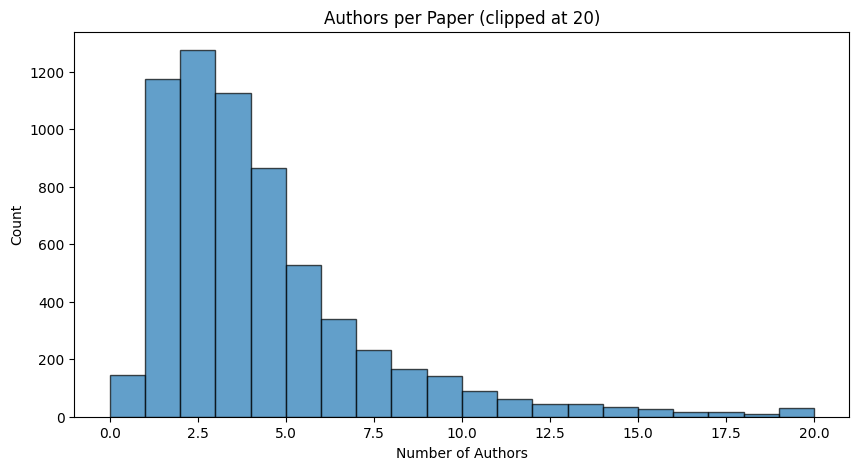

In [17]:
# Number of authors distribution
print('Authors per paper:')
print(meta_df['n_authors'].describe())
print(f'\nPapers with 0 authors: {(meta_df["n_authors"] == 0).sum()}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(meta_df['n_authors'].clip(upper=20), bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Authors')
ax.set_ylabel('Count')
ax.set_title('Authors per Paper (clipped at 20)')
plt.show()

In [18]:
# Data availability: abstract, funders, classification
print('Field availability:')
for col in ['has_abstract', 'has_funders', 'has_classification']:
    pct = meta_df[col].mean()
    print(f'  {col}: {pct:.1%}')

Field availability:
  has_abstract: 0.0%
  has_funders: 0.0%
  has_classification: 55.1%


In [19]:
# Check what classificationSchemes look like (e.g., PACS codes)
for json_file in (METADATA_DIR / 'PRA').rglob('*.json'):
    with open(json_file) as f:
        d = json.load(f)
    if 'classificationSchemes' in d:
        print(f'DOI: {d["id"]}')
        print(json.dumps(d['classificationSchemes'], indent=2))
        break

DOI: 10.1103/PhysRevA.103.013317
{
  "physh": {
    "disciplines": [
      {
        "id": "a48f173e-6459-4642-a711-a6e731807625",
        "label": "Condensed Matter, Materials & Applied Physics"
      }
    ],
    "concepts": [
      {
        "id": "05a47dcc-71c0-4ebc-9d4e-79a40a191efb",
        "label": "Many-body techniques",
        "facet": {
          "id": "233a6cd0-b7fe-491b-b5fd-85fd6b2a7c79",
          "label": "Theoretical & Computational Techniques"
        }
      },
      {
        "id": "a06f6c62-03c0-4084-bb03-a169845aad44",
        "label": "Variational approach",
        "facet": {
          "id": "233a6cd0-b7fe-491b-b5fd-85fd6b2a7c79",
          "label": "Theoretical & Computational Techniques"
        }
      },
      {
        "id": "4254adf6-872d-4868-9931-a2a3e84b566e",
        "label": "Bose-Einstein condensates",
        "facet": {
          "id": "f45b3c40-959c-4e90-ba0e-38232980802a",
          "label": "Physical Systems"
        }
      },
      {
        "

In [20]:
# Check what funders look like
for json_file in (METADATA_DIR / 'PRA').rglob('*.json'):
    with open(json_file) as f:
        d = json.load(f)
    if 'funders' in d:
        print(f'DOI: {d["id"]}')
        print(json.dumps(d['funders'], indent=2)[:500])
        break

## 3. Linking Citations ↔ Metadata

In [21]:
# Check overlap: how many citing/cited DOIs appear in our metadata?
meta_dois = set(meta_df['doi'])
all_citing = set(citations['citing_doi'])
all_cited = set(citations['cited_doi'])

# Since we only sampled ~6500 metadata records, compute overlap on that sample
citing_in_meta = len(meta_dois & all_citing)
cited_in_meta = len(meta_dois & all_cited)

print(f'Sampled metadata DOIs: {len(meta_dois):,}')
print(f'  Found as citing paper in citations: {citing_in_meta:,}')
print(f'  Found as cited paper in citations: {cited_in_meta:,}')
print(f'\nTotal unique DOIs in citations (either role): {len(all_citing | all_cited):,}')

Sampled metadata DOIs: 6,365
  Found as citing paper in citations: 5,357
  Found as cited paper in citations: 4,211

Total unique DOIs in citations (either role): 709,803


## 4. Summary

### Dataset Components

| Component | Description | Size |
|-----------|-------------|------|
| `aps-dataset-citations-2022.csv` | Citation edges (citing_doi, cited_doi) | ~9.8M rows |
| `aps-dataset-metadata-2022/` | Paper metadata as JSON files | ~196K files across 13 journals |

### Metadata Fields per Paper
- **id** (DOI), **title**, **date**
- **journal** (id, name, abbreviation)
- **volume**, **issue**, **pageStart/End**, **numPages**
- **articleType** (article, review, letter, etc.)
- **authors** (name, firstname, surname, affiliationIds)
- **affiliations** (id, name)
- **abstract** (when available)
- **classificationSchemes** (PACS/PhySH codes, when available)
- **funders** (when available)
- **rights** (copyright info)

### Key Notes
- Citations are **APS-internal only** (both citing and cited papers are APS publications)
- Metadata covers 13 APS journals from the early 1900s through 2022
- Not all papers have abstracts, funders, or classification schemes